<a href="https://colab.research.google.com/github/Humak1/get_carbon_intensity_data/blob/main/carbon_intensity_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regional carbon intensity forecasts: exploration, cleaning & analysis
**CATS Hackathon, Oxford** · Huma Kiyani

Data: [GreenScheduler/get_carbon_intensity_data](https://github.com/GreenScheduler/get_carbon_intensity_data), downloaded with CATS from [carbonintensity.org.uk](https://carbonintensity.org.uk/)

1. **Setup & load**
2. **Raw data:** looking at the data before changing anything
3. **Cleaning:** fixing only the problems Section 2 showed
4. **Analysis:** stats and graphs on the clean data
5. **Conclusions & limitations**

>  **My notes**
>
> **Aim.** I want to understand how the carbon intensity of electricity differs between the 14 UK regions and across the day. I also want to check how much the forecasts change before the time they predict. Finally, I want to estimate how much carbon a tool like CATS could save by moving a job to a cleaner time.
>
> My approach: I look at the raw data first, clean only what I can show is a problem, and then do the analysis. That way every cleaning decision has evidence behind it.

## 1. Setup & load

In [36]:
# I upload the zipped data folder (I need to do this every time the Colab session restarts)
import sys, os
if "google.colab" in sys.modules and not os.path.exists("carbon_intensity_data"):
    from google.colab import files
    files.upload()
    !unzip -q -o carbon_intensity_data.zip

In [37]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# I set a simple, consistent look for all my charts
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "axes.titlelocation": "left"})
BLUE, ORANGE, GREEN, PURPLE, RED = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#e34948"

DATA_DIR = Path("carbon_intensity_data")

In [38]:
# I read every CSV (one folder per region, one file per forecast run) into one table.
# The file name tells me the postcode and when the forecast was made, e.g. WC1E_2026-05-12T00:00:00+00:00.csv
frames = []
for f in sorted(DATA_DIR.glob("*/*.csv")):
    df = pd.read_csv(f)
    df["region"] = f.parent.name
    df["postcode"], df["forecast_issued"] = f.stem.split("_", 1)
    frames.append(df)
raw = pd.concat(frames, ignore_index=True)

# I turn the text dates into real UTC timestamps
raw["datetime"] = pd.to_datetime(raw["datetime"], utc=True, format="ISO8601")
raw["forecast_issued"] = pd.to_datetime(raw["forecast_issued"], utc=True, format="ISO8601")

# I work out how many hours ahead each forecast is
raw["horizon_h"] = (raw["datetime"] - raw["forecast_issued"]).dt.total_seconds() / 3600

print(f"{len(frames):,} files, {len(raw):,} rows, {raw.region.nunique()} regions")
raw.head()

9,574 files, 905,818 rows, 14 regions


,datetime,value,region,postcode,forecast_issued,horizon_h
0,2026-04-02 12:00:00+00:00,84,East_England,CB1,2026-04-02 12:00:00+00:00,0.0
1,2026-04-02 12:30:00+00:00,98,East_England,CB1,2026-04-02 12:00:00+00:00,0.5
2,2026-04-02 13:00:00+00:00,91,East_England,CB1,2026-04-02 12:00:00+00:00,1.0
3,2026-04-02 13:30:00+00:00,81,East_England,CB1,2026-04-02 12:00:00+00:00,1.5
4,2026-04-02 14:00:00+00:00,66,East_England,CB1,2026-04-02 12:00:00+00:00,2.0


**Columns**
- `datetime`: the half-hour being forecast (UTC)
- `value`: forecast carbon intensity, in gCO₂/kWh
- `forecast_issued`: when the forecast was made
- `horizon_h`: how many hours ahead the forecast is

## 2. Raw data: looking before changing anything

### 2.1 Structure and basic checks

In [39]:
# I check for missing values, duplicates and impossible (negative) values
raw.info()
print("\nmissing values:", raw.isna().sum().sum())
print("duplicate region + run + half-hour:", raw.duplicated(["region", "forecast_issued", "datetime"]).sum())
print("negative values:", (raw.value < 0).sum())
print("runs from", raw.forecast_issued.min(), "to", raw.forecast_issued.max())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 905818 entries, 0 to 905817
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype              
---  ------           --------------   -----              
 0   datetime         905818 non-null  datetime64[ns, UTC]
 1   value            905818 non-null  int64              
 2   region           905818 non-null  object             
 3   postcode         905818 non-null  object             
 4   forecast_issued  905818 non-null  datetime64[ns, UTC]
 5   horizon_h        905818 non-null  float64            
dtypes: datetime64[ns, UTC](2), float64(1), int64(1), object(2)
memory usage: 41.5+ MB

missing values: 0
duplicate region + run + half-hour: 0
negative values: 0
runs from 2026-04-02 12:00:00+00:00 to 2026-09-29 06:00:00+00:00


In [40]:
# I check each region has one postcode and roughly the same number of runs
raw.groupby("region").agg(postcode=("postcode", "first"),
                          runs=("forecast_issued", "nunique"),
                          rows=("value", "size"))

,postcode,runs,rows
region,,,
East_England,CB1,684,64715
East_Midlands,NG1,683,64619
London,WC1E,684,64715
North_East_England,NE1,685,64811
North_Scotland,IV1,685,64811
North_Wales_and_Merseyside,L1,684,64715
North_West_England,M1,685,64811
South_East_England,BN1,683,64619
South_England,OX1,683,64619


  **My notes**
>
> The raw data has **9,574 files and 905,818 rows**, with one row per forecast half-hour. There are 14 regions, each represented by a single postcode (e.g. London = WC1E), and each region has 683–685 forecast runs.
>
> - There are **no missing values, no duplicate rows and no negative values**, so the basic quality is good.
> - The runs go from **2 April to 29 September 2026**.
> - Each file is one 48-hour forecast in half-hour steps, so a complete file should have 96 rows.

### 2.2 Collection schedule

In [41]:
# I summarise each run: how many rows it has and how many regions were downloaded
runs = raw.groupby("forecast_issued").agg(rows=("value", "size"), regions=("region", "nunique"))
runs["rows_per_file"] = runs.rows / runs.regions

print("hour of day runs were made (UTC):\n", runs.index.hour.value_counts().sort_index().to_string())
print("\ntime between runs:\n", runs.index.to_series().diff().value_counts().head(6).to_string())

hour of day runs were made (UTC):
 forecast_issued
0     171
6     171
8       1
10      1
12    171
18    170

time between runs:
 forecast_issued
0 days 06:00:00    673
0 days 12:00:00      4
0 days 18:00:00      3
0 days 02:00:00      2
5 days 20:00:00      1
1 days 06:00:00      1


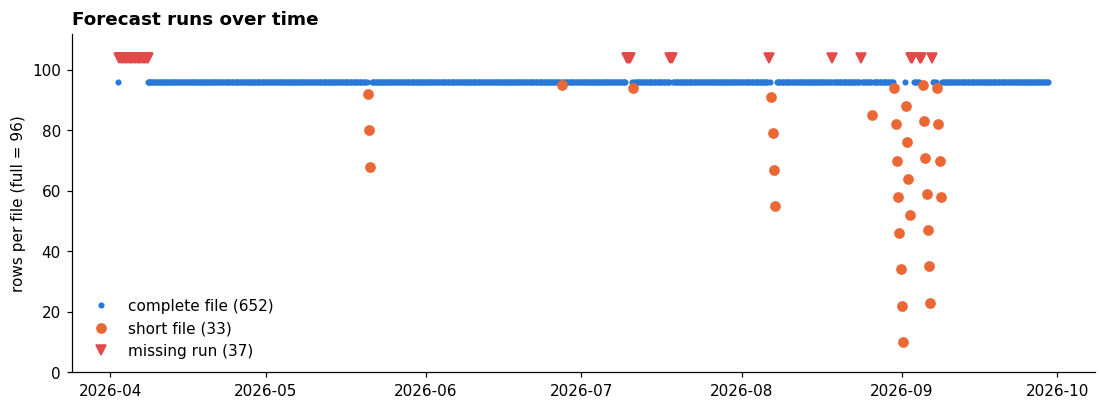

runs where only some regions were downloaded:
forecast_issued
2026-08-10 12:00:00+00:00    4
2026-08-22 18:00:00+00:00    8


In [42]:
# I compare against the expected schedule of one run every 6 hours
expected = pd.date_range(runs.index.min().ceil("6h"), runs.index.max(), freq="6h")
missing_runs = expected.difference(runs.index)
short_runs = runs[runs.rows_per_file < 96]
full_runs = runs[runs.rows_per_file == 96]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(full_runs.index, full_runs.rows_per_file, "o", ms=3, color=BLUE, label=f"complete file ({len(full_runs)})")
ax.plot(short_runs.index, short_runs.rows_per_file, "o", ms=6, color=ORANGE, label=f"short file ({len(short_runs)})")
ax.plot(missing_runs, [104] * len(missing_runs), "v", ms=7, color=RED, label=f"missing run ({len(missing_runs)})")
ax.set_ylim(0, 112)
ax.set_ylabel("rows per file (full = 96)")
ax.set_title("Forecast runs over time")
ax.legend(frameon=False, loc="lower left")
plt.show()

print("runs where only some regions were downloaded:")
print(runs[runs.regions < 14].regions.to_string())

>  **My notes**
>
> The data was collected **every 6 hours (00:00, 06:00, 12:00 and 18:00 UTC)**, and almost every gap between runs is exactly 6 hours. I found four problems:
>
> - **An early test period.** There is one run on 2 April, then a gap of nearly 6 days, then two off-schedule runs (08:00 and 10:00 on 8 April) before regular collection starts.
> - **37 missing runs.** 23 of these are in the gap between 2 and 8 April. The other 14 are scattered through July to September.
> - **2 partial runs**, where only some regions were downloaded: 10 Aug 12:00 (4 regions) and 22 Aug 18:00 (8 regions).
> - **33 short files** with fewer than 96 rows (down to just 10). They happen to all 14 regions at the same time, which suggests the problem is at the source, not in the download.

In [43]:
# I noticed the short files all happen to every region at once, so I checked when each short forecast ends.
# A normal forecast covers the next 48 h, so its end should move forward 6 h with every run.
ends = raw.groupby("forecast_issued").datetime.max()
pd.DataFrame({"rows": short_runs.rows_per_file.astype(int),
              "forecast ends": ends[short_runs.index]})

,rows,forecast ends
forecast_issued,,
2026-05-20 18:00:00+00:00,92,2026-05-22 15:30:00+00:00
2026-05-21 00:00:00+00:00,80,2026-05-22 15:30:00+00:00
2026-05-21 06:00:00+00:00,68,2026-05-22 15:30:00+00:00
2026-06-27 06:00:00+00:00,95,2026-06-29 05:00:00+00:00
2026-07-11 00:00:00+00:00,94,2026-07-12 22:30:00+00:00
2026-08-06 18:00:00+00:00,91,2026-08-08 15:00:00+00:00
2026-08-07 00:00:00+00:00,79,2026-08-08 15:00:00+00:00
2026-08-07 06:00:00+00:00,67,2026-08-08 15:00:00+00:00
2026-08-07 12:00:00+00:00,55,2026-08-08 15:00:00+00:00


Pattern I noticed. Consecutive short runs end at exactly the same time. For example, every run from 30 Aug 12:00 to 1 Sep 06:00 ends at 1 Sep 10:30, and the file gets 12 rows shorter every 6 hours. A normal forecast's end moves forward with each run, so a fixed end time suggests the source wasn't updating its forecast. If that's true, these runs should contain the same values as the run before, which I test in 2.3.

### 2.3 Are any runs just copies of the previous run?
Each half-hour gets forecast by several runs. A genuinely new run should update at least some of those values.

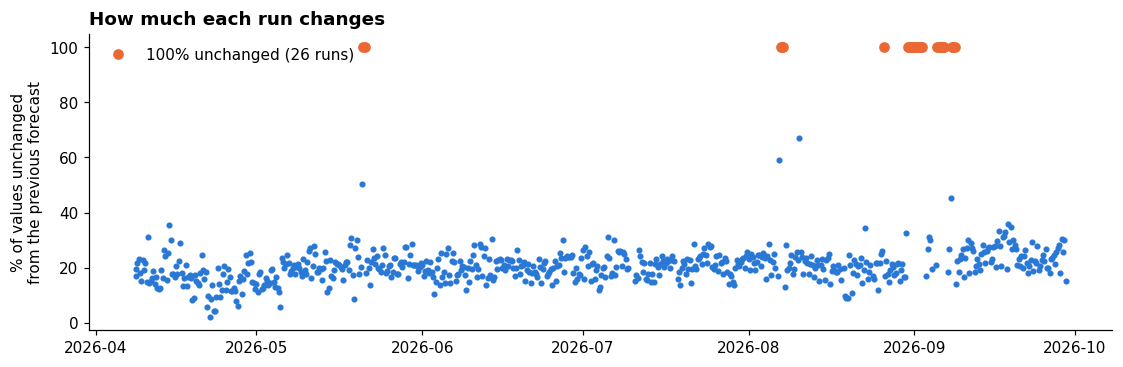

frozen runs: ['2026-05-21 00:00:00+00:00', '2026-05-21 06:00:00+00:00', '2026-08-07 00:00:00+00:00', '2026-08-07 06:00:00+00:00', '2026-08-07 12:00:00+00:00', '2026-08-26 06:00:00+00:00', '2026-08-30 18:00:00+00:00', '2026-08-31 00:00:00+00:00', '2026-08-31 06:00:00+00:00', '2026-08-31 12:00:00+00:00', '2026-08-31 18:00:00+00:00', '2026-09-01 00:00:00+00:00', '2026-09-01 06:00:00+00:00', '2026-09-01 18:00:00+00:00', '2026-09-02 00:00:00+00:00', '2026-09-02 06:00:00+00:00', '2026-09-02 12:00:00+00:00', '2026-09-05 06:00:00+00:00', '2026-09-05 12:00:00+00:00', '2026-09-05 18:00:00+00:00', '2026-09-06 00:00:00+00:00', '2026-09-06 06:00:00+00:00', '2026-09-06 12:00:00+00:00', '2026-09-08 00:00:00+00:00', '2026-09-08 06:00:00+00:00', '2026-09-08 12:00:00+00:00']
all frozen runs are also short files: True


In [44]:
# For each region and half-hour, I sort the forecasts by when they were made
# and check whether each one is the same as the forecast just before it
x = raw.sort_values(["region", "datetime", "forecast_issued"])
x["same_as_before"] = x.groupby(["region", "datetime"]).value.diff().eq(0)
x["has_earlier"] = x.groupby(["region", "datetime"]).cumcount() > 0

# For each run, I work out the % of its values that didn't change
share_same = x[x.has_earlier].groupby("forecast_issued").same_as_before.mean()
frozen_runs = share_same[share_same == 1].index      # 100% unchanged = a copy

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(share_same.index, share_same * 100, "o", ms=3, color=BLUE)
ax.plot(frozen_runs, [100] * len(frozen_runs), "o", ms=6, color=ORANGE, label=f"100% unchanged ({len(frozen_runs)} runs)")
ax.set_ylabel("% of values unchanged\nfrom the previous forecast")
ax.set_title("How much each run changes")
ax.legend(frameon=False)
plt.show()

print("frozen runs:", [str(t) for t in frozen_runs])
print("all frozen runs are also short files:", set(frozen_runs) <= set(short_runs.index))

**My notes**
>
> A normal run leaves only about **20% of its overlapping values unchanged** (typically 17–23%), meaning it revises most of the forecast. But **26 runs are 100% identical** to the forecast before them. They fall on 21 May, 7 Aug, 26 Aug, 30 Aug–2 Sep, 5–6 Sep and 8 Sep.
>
> All 26 are also short files from 2.2. What seems to happen is that the source API stops updating its forecast. Each new download then returns the same old forecast, and it gets shorter every 6 hours because its end time stays fixed.
>
> These runs contain no new information. If I kept them, they would count old forecasts twice and make the forecasts look more stable than they really are. **I will remove them in cleaning.** I couldn't have found this with basic checks like duplicates or missing values.

Frozen files


In [45]:
for t in frozen_runs:
    print(t.strftime("%Y-%m-%dT%H:%M:%S+00:00"))

2026-05-21T00:00:00+00:00
2026-05-21T06:00:00+00:00
2026-08-07T00:00:00+00:00
2026-08-07T06:00:00+00:00
2026-08-07T12:00:00+00:00
2026-08-26T06:00:00+00:00
2026-08-30T18:00:00+00:00
2026-08-31T00:00:00+00:00
2026-08-31T06:00:00+00:00
2026-08-31T12:00:00+00:00
2026-08-31T18:00:00+00:00
2026-09-01T00:00:00+00:00
2026-09-01T06:00:00+00:00
2026-09-01T18:00:00+00:00
2026-09-02T00:00:00+00:00
2026-09-02T06:00:00+00:00
2026-09-02T12:00:00+00:00
2026-09-05T06:00:00+00:00
2026-09-05T12:00:00+00:00
2026-09-05T18:00:00+00:00
2026-09-06T00:00:00+00:00
2026-09-06T06:00:00+00:00
2026-09-06T12:00:00+00:00
2026-09-08T00:00:00+00:00
2026-09-08T06:00:00+00:00
2026-09-08T12:00:00+00:00


In [46]:
# I group every run by how much it changed compared with the previous forecasts, to see if there's a clear split
pd.cut(share_same * 100, [0, 50, 80, 99.99, 100], include_lowest=True,
       labels=["0–50%", "50–80%", "80–99%", "100%"]).value_counts().sort_index()

,count
same_as_before,
0–50%,652
50–80%,3
80–99%,0
100%,26


In [47]:
# I spot-check one example: every London forecast made for 1 Sep 06:00–10:30
example = raw[(raw.region == "London") &
              raw.datetime.between("2026-09-01 06:00", "2026-09-01 10:30")]
example.pivot_table(index="datetime", columns="forecast_issued", values="value")

forecast_issued,2026-08-30 12:00:00+00:00,2026-08-30 18:00:00+00:00,2026-08-31 00:00:00+00:00,2026-08-31 06:00:00+00:00,2026-08-31 12:00:00+00:00,2026-08-31 18:00:00+00:00,2026-09-01 00:00:00+00:00,2026-09-01 06:00:00+00:00
datetime,,,,,,,,
2026-09-01 06:00:00+00:00,172.0,172.0,172.0,172.0,172.0,172.0,172.0,172.0
2026-09-01 06:30:00+00:00,145.0,145.0,145.0,145.0,145.0,145.0,145.0,145.0
2026-09-01 07:00:00+00:00,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0
2026-09-01 07:30:00+00:00,121.0,121.0,121.0,121.0,121.0,121.0,121.0,121.0
2026-09-01 08:00:00+00:00,121.0,121.0,121.0,121.0,121.0,121.0,121.0,121.0
2026-09-01 08:30:00+00:00,114.0,114.0,114.0,114.0,114.0,114.0,114.0,114.0
2026-09-01 09:00:00+00:00,114.0,114.0,114.0,114.0,114.0,114.0,114.0,114.0
2026-09-01 09:30:00+00:00,115.0,115.0,115.0,115.0,115.0,115.0,115.0,115.0
2026-09-01 10:00:00+00:00,115.0,115.0,115.0,115.0,115.0,115.0,115.0,115.0


**How I found the frozen runs.** The short files were the first clue. Following them up (2.2) showed their end time stopped moving, which suggested the forecast wasn't being updated. To test this, I compared every forecast with the previous forecast for the same region and half-hour.

**Result.** The runs split into two clear groups: 652 runs changed most of their values (typically only about 20% unchanged), 3 changed less, none fell between 80% and 99%, and 26 were 100% identical. A gap that clean means these aren't quiet forecasts. They are copies. The London example confirms it: all 8 runs from 30 Aug 12:00 to 1 Sep 06:00 give exactly the same 10 values. All 26 frozen runs are also short files, which matches the fixed end time.

**Interpretation and decision.** The source API(potentially) seems to have stopped updating during 7 episodes (the longest was 42 hours), and the download kept saving the last forecast. Basic duplicate checks can't catch this, because each copy has a different issue time. I remove these runs in Section 3 rather than filling them in, because they would count old forecasts several times and make forecasts look more stable than they are.

### 2.4 Value distributions by region

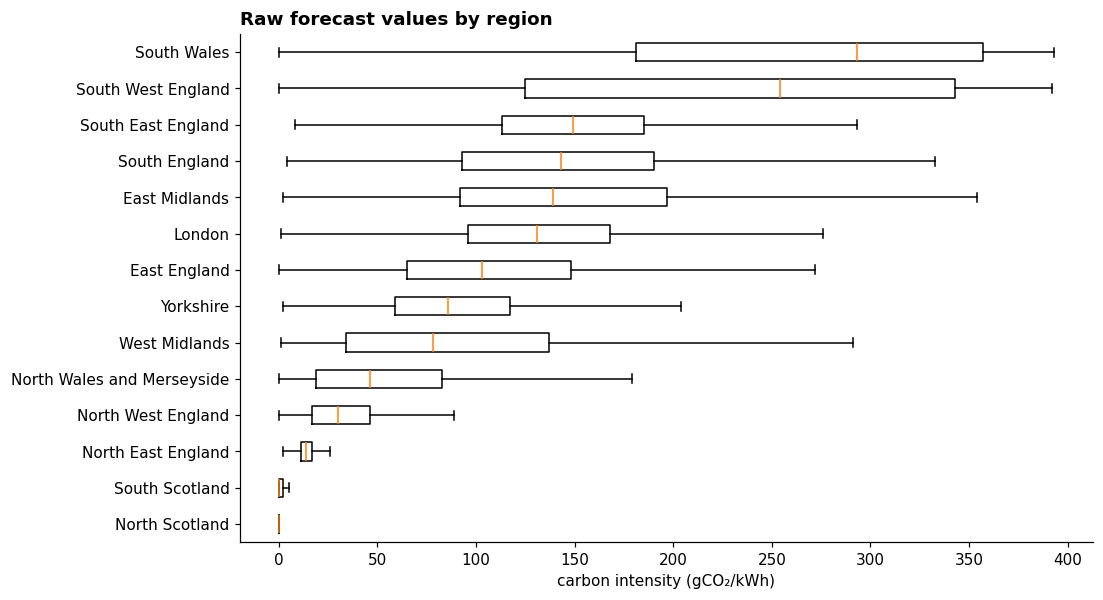

,count,mean,std,min,25%,50%,75%,max,% zeros
region,,,,,,,,,
North_Scotland,64811.0,0.0,1.0,0.0,0.0,0.0,0.0,25.0,95.3
South_Scotland,64811.0,1.0,3.0,0.0,0.0,0.0,2.0,40.0,50.6
North_East_England,64811.0,14.0,5.0,0.0,11.0,14.0,17.0,71.0,0.1
North_West_England,64811.0,33.0,20.0,0.0,17.0,30.0,46.0,137.0,0.0
North_Wales_and_Merseyside,64715.0,57.0,47.0,0.0,19.0,46.0,83.0,352.0,0.5
West_Midlands,64619.0,90.0,63.0,1.0,34.0,78.0,137.0,339.0,0.0
Yorkshire,64619.0,90.0,40.0,2.0,59.0,86.0,117.0,283.0,0.0
East_England,64715.0,110.0,59.0,0.0,65.0,103.0,148.0,332.0,0.1
London,64715.0,134.0,49.0,1.0,96.0,131.0,168.0,385.0,0.0


In [48]:
# I sort the regions by median so the boxplot reads from cleanest to dirtiest
order = raw.groupby("region").value.median().sort_values().index

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot([raw.loc[raw.region == r, "value"] for r in order], vert=False, showfliers=False,
           tick_labels=[r.replace("_", " ") for r in order])
ax.set_xlabel("carbon intensity (gCO₂/kWh)")
ax.set_title("Raw forecast values by region")
plt.show()

# I add the % of zeros because Scotland looked unusual
summary = raw.groupby("region").value.describe().loc[order].round(0)
summary["% zeros"] = (raw.value.eq(0).groupby(raw.region).mean() * 100).round(1)
summary

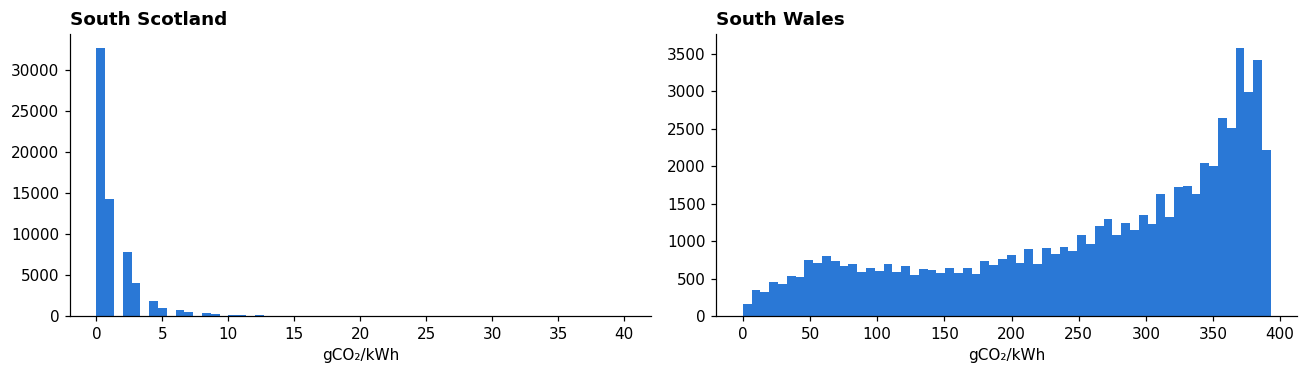

In [49]:
# I zoom in on the two extremes: a low-carbon region and a high-carbon region
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, r in zip(axes, ["South_Scotland", "South_Wales"]):
    ax.hist(raw.loc[raw.region == r, "value"], bins=60, color=BLUE)
    ax.set_title(r.replace("_", " "))
    ax.set_xlabel("gCO₂/kWh")
plt.tight_layout()
plt.show()

>  **My notes**
>
> The regions are very different. **North Scotland** has a median of **0** and **South Wales** has a median of **293 gCO₂/kWh**. Roughly, intensity rises from north to south-west.
>
> - **Zeros:** North Scotland is 0 in **95%** of rows and South Scotland in **51%**. I think these are real, not errors. The values are whole numbers, and Scottish electricity is mostly wind, hydro and nuclear, so a very small value rounds down to 0. **I will keep them.**
> - **High values:** South Wales and the South West pile up just below **~390** and never go above 393. This looks like a natural ceiling, roughly what you get when the region is supplied almost entirely by gas, rather than outliers. **I will keep them too.**

### 2.5 The raw time series

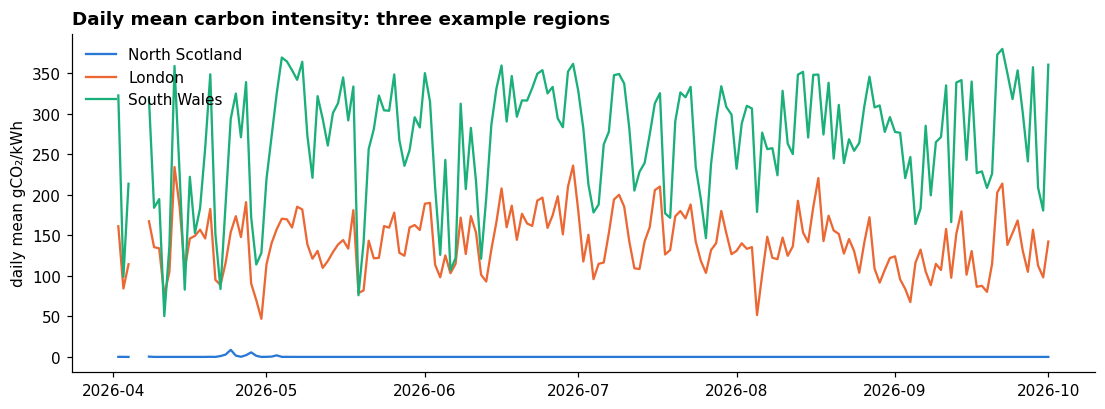

In [50]:
# For a first look I keep just the most recent forecast of each half-hour
latest = raw.sort_values("horizon_h").drop_duplicates(["region", "datetime"]).sort_values("datetime")
show = {"North_Scotland": BLUE, "London": ORANGE, "South_Wales": GREEN}

fig, ax = plt.subplots(figsize=(12, 4))
for r, c in show.items():
    daily_mean = latest[latest.region == r].set_index("datetime").value.resample("1D").mean()
    ax.plot(daily_mean.index, daily_mean.values, color=c, label=r.replace("_", " "))
ax.set_ylabel("daily mean gCO₂/kWh")
ax.set_title("Daily mean carbon intensity: three example regions")
ax.legend(frameon=False)
plt.show()

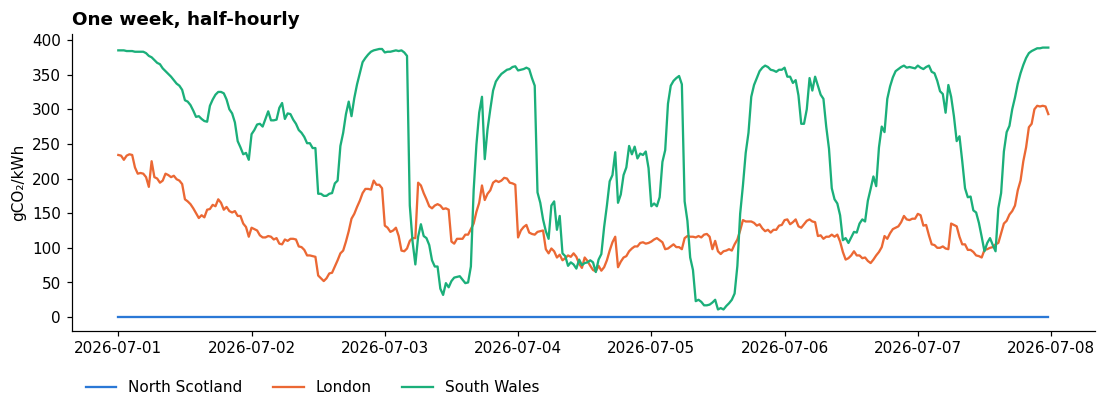

In [51]:
# I zoom in on one week to see the daily cycle
week = latest[(latest.datetime >= "2026-07-01") & (latest.datetime < "2026-07-08")]

fig, ax = plt.subplots(figsize=(12, 3.5))
for r, c in show.items():
    d = week[week.region == r]
    ax.plot(d.datetime, d.value, color=c, label=r.replace("_", " "))
ax.set_ylabel("gCO₂/kWh")
ax.set_title("One week, half-hourly")
ax.legend(frameon=False, ncol=3, loc="upper left", bbox_to_anchor=(0, -0.12))
plt.show()

>  **My notes**
>
> The daily means move around a lot from day to day. **London ranges from about 46 to 236 g** and **South Wales from about 52 to 380 g**, which is probably weather-driven. North Scotland stays close to 0 the whole time.
>
> The one-week zoom shows a clear **daily cycle**: low around midday and high in the evening. The cycle is much bigger in South Wales than in London.
>
> Two things to fix:
> - There is a visible gap at the start of April (the test period).
> - The series runs about **2 days past the last download**, because the last run forecasts 48 hours ahead. Those future half-hours were never updated, so I'll cut them off.

### 2.6 One half-hour, many forecasts

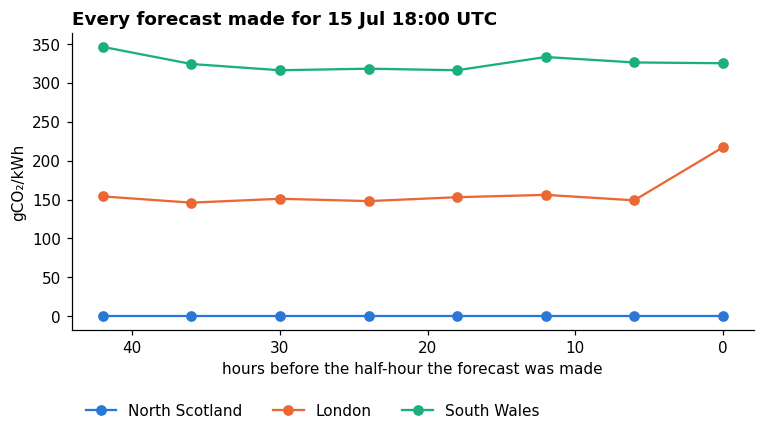

In [52]:
# I pick one half-hour and plot every forecast that was made for it
target = pd.Timestamp("2026-07-15 18:00", tz="UTC")
ex = raw[(raw.datetime == target) & raw.region.isin(show)]

fig, ax = plt.subplots(figsize=(8, 3.5))
for r, c in show.items():
    d = ex[ex.region == r].sort_values("horizon_h")
    ax.plot(d.horizon_h, d.value, "o-", color=c, label=r.replace("_", " "))
ax.invert_xaxis()
ax.set_xlabel("hours before the half-hour the forecast was made")
ax.set_ylabel("gCO₂/kWh")
ax.set_title(f"Every forecast made for {target:%d %b %H:%M} UTC")
ax.legend(frameon=False, ncol=3, loc="upper left", bbox_to_anchor=(0, -0.2))
plt.show()

>  **My notes**
>
> Each half-hour was forecast **8 times**, from 42 hours ahead down to the last moment. For 15 July 18:00:
> - **London's** forecast sat at **146–156 g** for almost two days, then the final forecast jumped to **217 g**.
> - **South Wales** moved between **316 and 346 g**.
> - **North Scotland** was 0 every time.
>
> So I need to choose **one value per half-hour** for the pattern analysis. I'll use the most recent forecast, because it is closest to what actually happened. I'll keep all the forecasts separately to measure how much they change.
>
> **Summary of what needs cleaning:** remove the April test runs, remove the 26 frozen runs, keep one value per half-hour, cut the future tail, and convert to UK time for daily patterns.

## 3. Cleaning

In [53]:
# I keep a log of every cleaning step so I can report exactly what I removed and why
log = []
def record(step, before, after, why):
    log.append({"step": step, "rows before": before, "rows after": after, "removed": before - after, "why": why})

ci = raw.copy()

**Step 1: drop the test runs before 8 April**

In [54]:
n = len(ci)
ci = ci[ci.forecast_issued >= "2026-04-08"]
record("drop runs before 8 Apr", n, len(ci), "isolated test run before regular 6-hourly collection")

>  **My notes**
>
> I start on **8 April**, the first day of regular collection. Before that there is only one test run, followed by a 6-day gap. Keeping it would add an isolated snapshot that doesn't fit the rest of the series.

**Step 2: remove the frozen runs**

In [55]:
n = len(ci)
ci = ci[~ci.forecast_issued.isin(frozen_runs)]
record("drop frozen runs", n, len(ci), "26 runs identical to the previous forecast (API not updating)")

>  **My notes**
>
> I remove the **26 frozen runs** (21,896 rows). They are copies of an earlier forecast, not new forecasts. Keeping them would count the same values twice and make forecasts look more stable than they are. I **don't** remove the other 7 short files, because they still contain genuinely updated values. They're just shorter.

**Step 3: one value per region per half-hour**

In [56]:
# For each region and half-hour I keep the most recent forecast (the smallest horizon)
best = ci.sort_values("horizon_h").drop_duplicates(["region", "datetime"])

# I cut half-hours after the last run + 6 h, because they are 'future' forecasts that were never updated
cutoff = ci.forecast_issued.max() + pd.Timedelta("6h")
n = len(best)
best = best[best.datetime < cutoff].sort_values(["region", "datetime"])
record("best series: drop future tail", n, len(best), "half-hours after the last run were never updated")

print(best.horizon_h.describe().round(1))

count    116998.0
mean          3.7
std           5.0
min           0.0
25%           1.5
50%           3.0
75%           4.5
max          47.0
Name: horizon_h, dtype: float64


**Step 4: check for gaps and add UK local time**

In [57]:
# I check whether any half-hours have no forecast at all
all_halfhours = pd.date_range(best.datetime.min(), best.datetime.max(), freq="30min")
gaps = all_halfhours.difference(best.loc[best.region == "London", "datetime"])
print("half-hours with no forecast:", [str(g) for g in gaps])

# I convert to UK time (BST) because daily patterns follow local clocks, not UTC
best["local"] = best.datetime.dt.tz_convert("Europe/London")
best["hour"] = best.local.dt.hour
best["date"] = best.local.dt.date
best["month"] = best.local.dt.month
best["weekend"] = best.local.dt.dayofweek >= 5

half-hours with no forecast: ['2026-09-01 11:00:00+00:00', '2026-09-01 11:30:00+00:00', '2026-09-06 23:30:00+00:00']


In [58]:
pd.DataFrame(log)

,step,rows before,rows after,removed,why
0,drop runs before 8 Apr,905818,904474,1344,isolated test run before regular 6-hourly coll...
1,drop frozen runs,904474,882578,21896,26 runs identical to the previous forecast (AP...
2,best series: drop future tail,118174,116998,1176,half-hours after the last run were never updated


>  **My notes**
>
> **Cleaning summary**
>
> | Step | Rows removed | Why |
> |---|---|---|
> | Runs before 8 April | 1,344 | isolated test run |
> | Frozen runs | 21,896 | copies of an earlier forecast |
> | Future tail | 1,176 | never updated |
>
> - That leaves **882,578 forecast rows** (`ci`, used for the forecast analysis) and **116,998 half-hour values** (`best`, 14 regions × about 175 days, used for everything else).
> - The "best" value is usually only **3 hours** old (median horizon). It's older only during the gaps.
> - Only **3 half-hours have no forecast at all** (1 Sep 11:00–11:30 and 6 Sep 23:30). That's so few that I leave them as gaps rather than filling them in.
>
> **What I deliberately kept:** Scotland's zeros and the values near 390 in the south-west. Both are real features of the grid, not errors.

## 4. Analysis

### 4.1 Summary statistics by region

In [59]:
order = best.groupby("region").value.median().sort_values().index
table = best.groupby("region").value.agg(["mean", "median", "std", "min", "max"]).loc[order].round(0)
table["% time < 50 g"] = ((best.value < 50).groupby(best.region).mean() * 100).round(0)
table["% time > 200 g"] = ((best.value > 200).groupby(best.region).mean() * 100).round(0)
table

,mean,median,std,min,max,% time < 50 g,% time > 200 g
region,,,,,,,
North_Scotland,0.0,0.0,1.0,0,15,100.0,0.0
South_Scotland,1.0,0.0,3.0,0,40,100.0,0.0
North_East_England,15.0,15.0,6.0,0,47,100.0,0.0
North_West_England,36.0,32.0,23.0,0,137,75.0,0.0
North_Wales_and_Merseyside,61.0,47.0,53.0,0,352,52.0,2.0
West_Midlands,98.0,83.0,70.0,1,307,33.0,11.0
Yorkshire,95.0,90.0,43.0,3,283,14.0,1.0
East_England,121.0,115.0,64.0,0,326,14.0,12.0
London,142.0,139.0,55.0,1,308,2.0,17.0


>  **My notes**
>
> - **Cleanest:** North and South Scotland (mean about 0–1 g) and the North East (15 g). All three are below 50 g **100% of the time**.
> - **Dirtiest:** South Wales (mean **270 g**) and the South West (**249 g**). They are above 200 g for **74%** and **65%** of the time.
> - **London** sits in the middle, with a mean of **142 g**. It's below 50 g only **2%** of the time and above 200 g **17%** of the time.
> - The regions differ most in their **spread**. South Wales and the South West have standard deviations over 100 g, so they swing a lot, while the north is steady.

### 4.2 Regional comparison

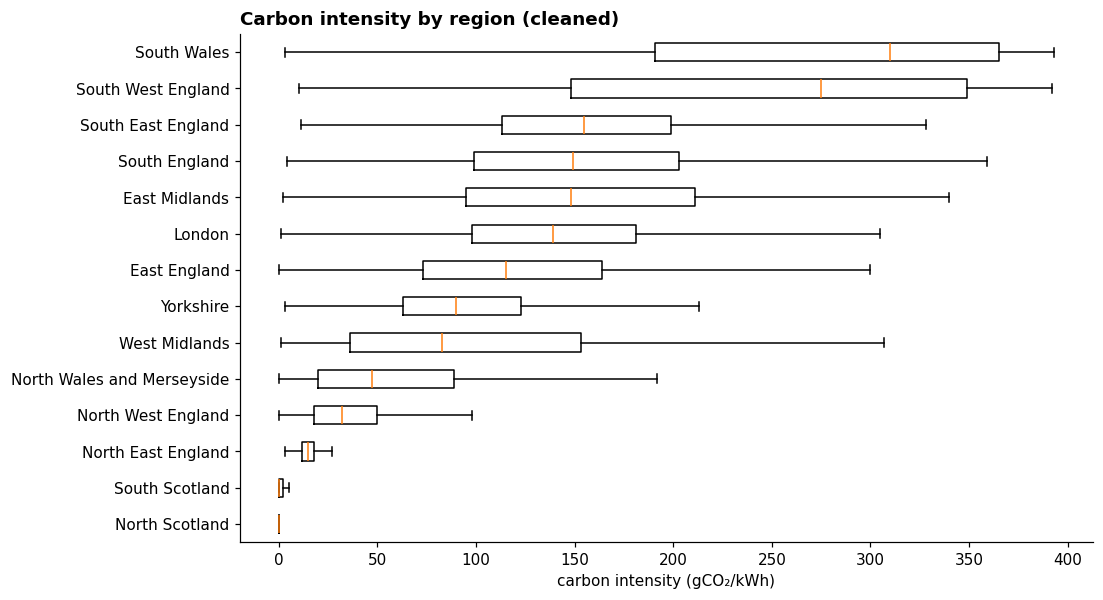

In [60]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot([best.loc[best.region == r, "value"] for r in order], vert=False, showfliers=False,
           tick_labels=[r.replace("_", " ") for r in order])
ax.set_xlabel("carbon intensity (gCO₂/kWh)")
ax.set_title("Carbon intensity by region (cleaned)")
plt.show()

>  **My notes**
>
> After cleaning, the ranking is the same as in the raw data, so cleaning didn't change the overall picture. The boxes show a clear north-to-south-west gradient. The wide boxes for the South West and South Wales mean that *when* you use electricity there matters much more than in other regions.

### 4.3 Time of day

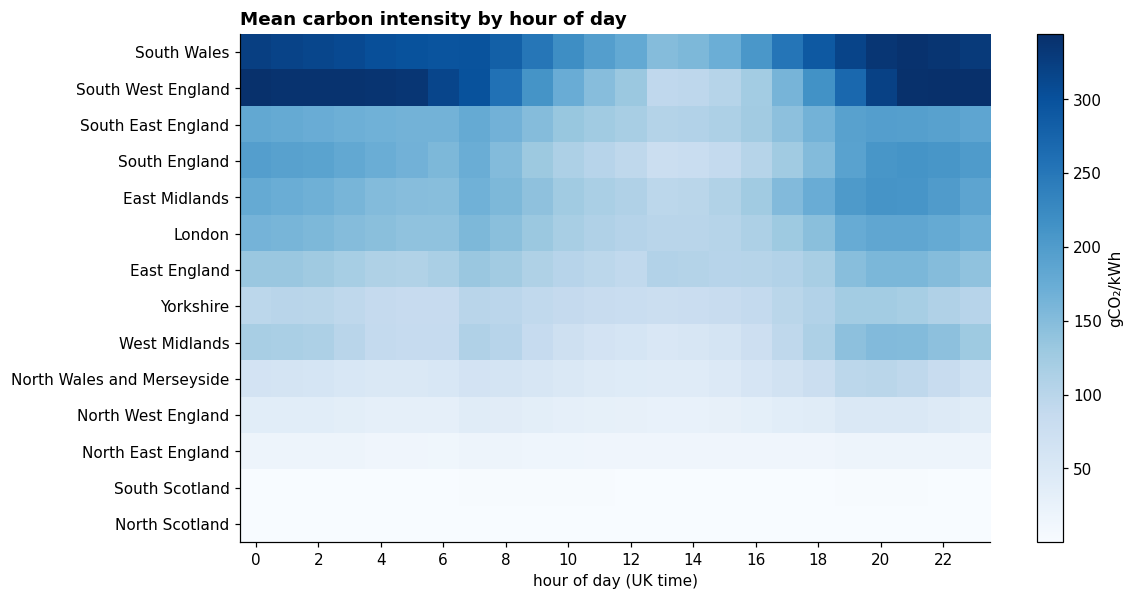

In [61]:
# I average each region by hour of day and show it as a heatmap
heat = best.pivot_table(index="region", columns="hour", values="value").loc[order[::-1]]

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(heat, aspect="auto", cmap="Blues")
ax.set_yticks(range(len(heat)), [r.replace("_", " ") for r in heat.index])
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("hour of day (UK time)")
ax.set_title("Mean carbon intensity by hour of day")
fig.colorbar(im, label="gCO₂/kWh")
plt.show()

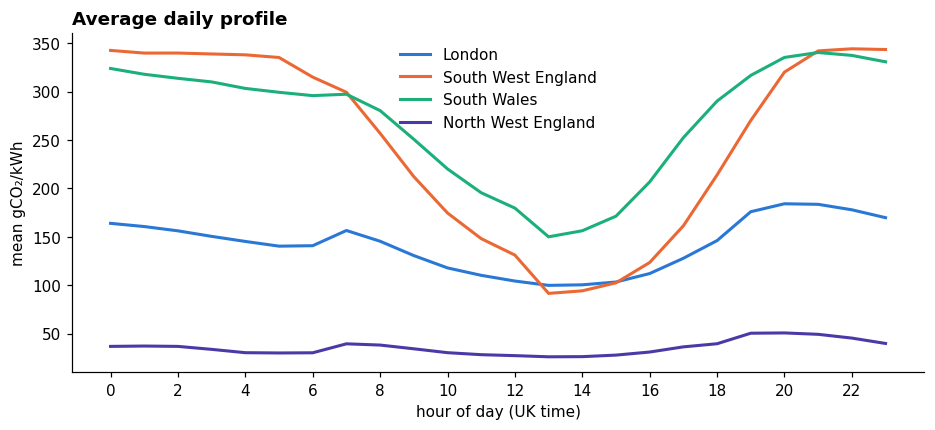

In [62]:
# I compare the average daily shape of four contrasting regions
compare = {"London": BLUE, "South_West_England": ORANGE, "South_Wales": GREEN, "North_West_England": PURPLE}

fig, ax = plt.subplots(figsize=(10, 4))
for r, c in compare.items():
    profile = best[best.region == r].groupby("hour").value.mean()
    ax.plot(profile.index, profile.values, lw=2, color=c, label=r.replace("_", " "))
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("hour of day (UK time)")
ax.set_ylabel("mean gCO₂/kWh")
ax.set_title("Average daily profile")
ax.legend(frameon=False)
plt.show()

>  **My notes**
>
> Every region is **cleanest around 13:00** and **dirtiest in the evening (20:00–22:00)**, which fits solar output peaking at midday and demand peaking in the evening.
>
> | Region | 13:00 | Evening peak |
> |---|---|---|
> | London | 100 g | 184 g (20:00) |
> | South West | 92 g | 344 g (22:00) |
> | South Wales | 150 g | 340 g (21:00) |
> | North West | 26 g | 51 g (20:00) |
>
> The **South West has the biggest daily swing**, almost 4× between midday and night, which is probably because it has a lot of solar. At midday it's actually cleaner than London, even though it's one of the dirtiest regions overall.

### 4.4 Weekday vs weekend, and month by month

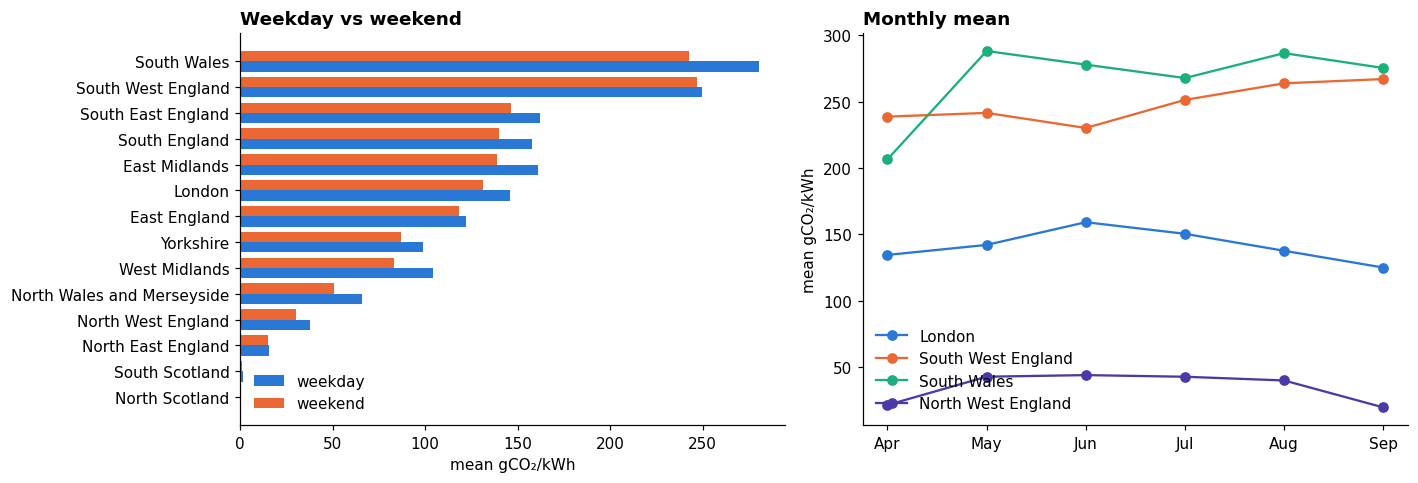

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# weekday vs weekend mean for each region
ww = best.groupby(["region", "weekend"]).value.mean().unstack().loc[order]
y = np.arange(len(ww))
axes[0].barh(y - 0.2, ww[False], height=0.4, color=BLUE, label="weekday")
axes[0].barh(y + 0.2, ww[True], height=0.4, color=ORANGE, label="weekend")
axes[0].set_yticks(y, [r.replace("_", " ") for r in ww.index])
axes[0].set_xlabel("mean gCO₂/kWh")
axes[0].set_title("Weekday vs weekend")
axes[0].legend(frameon=False)

# monthly mean for my four comparison regions
monthly = best.groupby(["month", "region"]).value.mean().unstack()
for r, c in compare.items():
    axes[1].plot(monthly.index, monthly[r], "o-", color=c, label=r.replace("_", " "))
axes[1].set_xticks(monthly.index, ["Apr", "May", "Jun", "Jul", "Aug", "Sep"])
axes[1].set_ylabel("mean gCO₂/kWh")
axes[1].set_title("Monthly mean")
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

>  **My notes**
>
> **Weekends are cleaner in almost every region**, because demand is lower:
> - London, the South East and the South are about 10% lower.
> - The West Midlands and North West are about 20% lower.
> - North Wales & Merseyside is 23% lower.
> - The South West (−1%) and East England (−3%) barely change.
>
> **Month by month** there isn't a strong trend over April–September. London peaks in June (159 g) and is lowest in September (125 g). South Wales was lower in April (207 g) than the rest of the summer (about 270–290 g). This only covers six months, so I can't say anything about winter.

### 4.5 Statistical tests
I test on **daily means** rather than half-hourly values. Half-hours next to each other are strongly related, so treating each one as independent would make almost any difference look "significant".

In [64]:
daily = best.groupby(["date", "region"]).value.mean().unstack()
print("days:", len(daily))

# Do the regions differ at all? (Kruskal–Wallis, because the data isn't normally distributed)
h, p = stats.kruskal(*[daily[r].dropna() for r in daily.columns])
print(f"Kruskal–Wallis: H = {h:.0f}, p = {p:.2g}")

# Pairwise: I compare two regions on the same days (Wilcoxon signed-rank)
# and report the size of the difference, not just the p-value
def compare_regions(a, b):
    d = daily[[a, b]].dropna()
    p = stats.wilcoxon(d[a], d[b]).pvalue
    diff = (d[a] - d[b]).median()
    lower = (d[a] < d[b]).mean() * 100
    print(f"{a} vs {b}: median difference {diff:.0f} g, {a} lower on {lower:.0f}% of days, p = {p:.2g}")

compare_regions("South_Scotland", "London")
compare_regions("London", "South_East_England")
compare_regions("London", "South_West_England")
compare_regions("North_West_England", "London")

days: 175
Kruskal–Wallis: H = 2062, p = 0
South_Scotland vs London: median difference -140 g, South_Scotland lower on 100% of days, p = 1.8e-30
London vs South_East_England: median difference -14 g, London lower on 80% of days, p = 1e-20
London vs South_West_England: median difference -108 g, London lower on 100% of days, p = 1.8e-30
North_West_England vs London: median difference -102 g, North_West_England lower on 100% of days, p = 1.8e-30


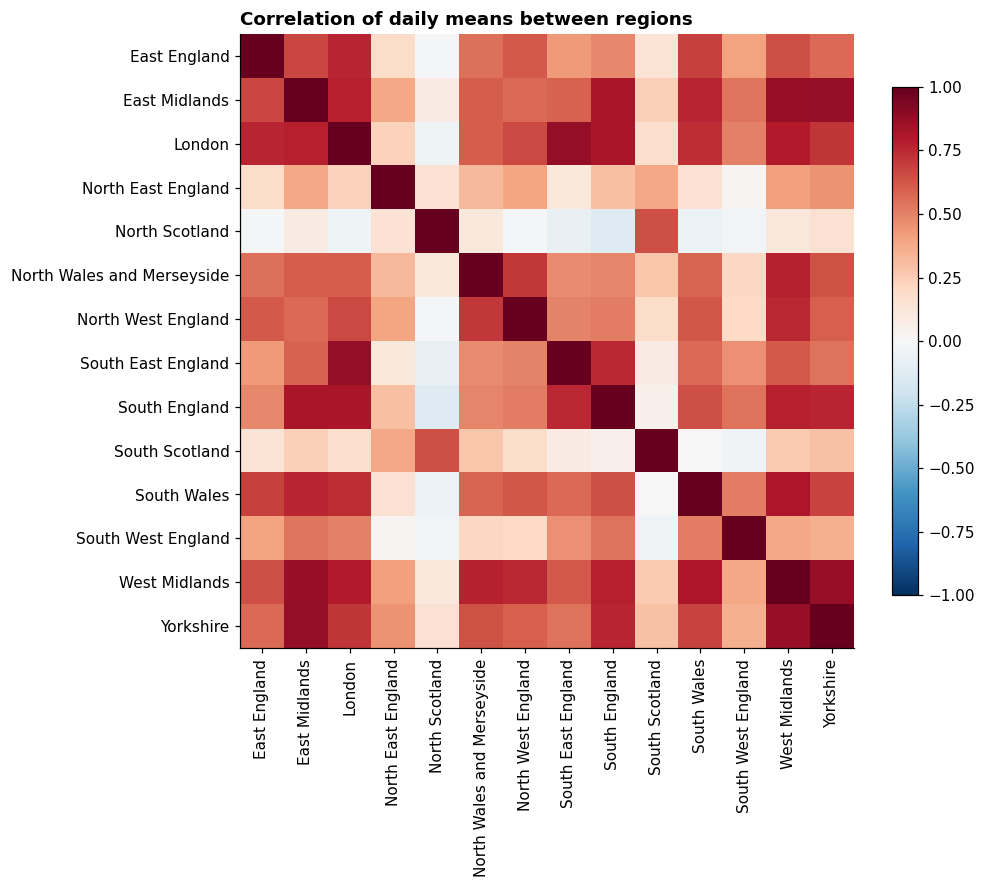

In [65]:
# Which regions go up and down together?
corr = daily.corr()
labels = [r.replace("_", " ") for r in corr.columns]

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=90)
ax.set_yticks(range(len(labels)), labels)
ax.set_title("Correlation of daily means between regions")
fig.colorbar(im, shrink=0.8)
plt.show()

>  **My notes**
>
> Across **175 days**, the regions clearly differ (Kruskal–Wallis H = 2062, p ≈ 0).
>
> | Comparison | Median daily difference | Lower region wins on | p |
> |---|---|---|---|
> | South Scotland vs London | −140 g | 100% of days | 2e-30 |
> | London vs South West | −108 g | 100% of days | 2e-30 |
> | North West vs London | −102 g | 100% of days | 2e-30 |
> | London vs South East | −14 g | 80% of days | 1e-20 |
>
> **Scotland vs London isn't an interesting test on its own.** Scotland is lower on every single day, so the p-value just confirms what the boxplot already shows. The **effect sizes** tell me more. London vs the South East is the only close comparison: London is only about 14 g cleaner, and the South East is actually cleaner on 20% of days.
>
> **Correlations:** neighbouring regions move together. The strongest pairs are London–South East, East Midlands–Yorkshire, East–West Midlands and West Midlands–Yorkshire, all 0.87–0.88. North Scotland barely correlates with any English or Welsh region (between −0.13 and 0.16), but it does with South Scotland (0.64). This suggests Scotland's grid behaves separately from the rest of Britain.

### 4.6 How much do forecasts change as the time approaches?
The regional API only provides **forecasts**, not measured values. So I compare earlier forecasts with the most recent one (made 0–6 h ahead). That measures *forecast revision*, not true accuracy.

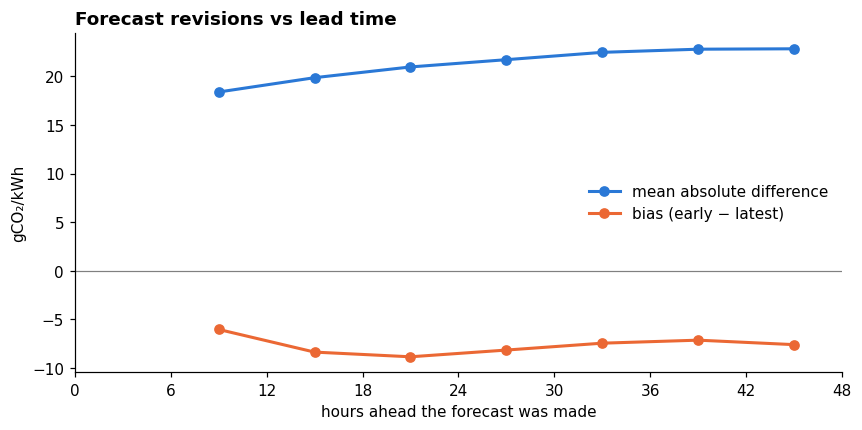

In [66]:
# The most recent forecast of each half-hour is my reference
ref = best[best.horizon_h < 6][["region", "datetime", "value"]].rename(columns={"value": "ref"})

# I match every earlier forecast to that reference and work out the difference
rev = ci.merge(ref, on=["region", "datetime"])
rev = rev[rev.horizon_h >= 6]
rev["error"] = rev.value - rev.ref
rev["lead"] = rev.horizon_h // 6 * 6 + 3            # group into 6-hour bands (6–12 h, 12–18 h, …)

mae = rev.error.abs().groupby(rev.lead).mean()      # average size of the change
bias = rev.error.groupby(rev.lead).mean()           # average direction of the change

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mae.index, mae.values, "o-", color=BLUE, lw=2, label="mean absolute difference")
ax.plot(bias.index, bias.values, "o-", color=ORANGE, lw=2, label="bias (early − latest)")
ax.axhline(0, color="grey", lw=0.8)
ax.set_xticks(range(0, 49, 6))
ax.set_xlabel("hours ahead the forecast was made")
ax.set_ylabel("gCO₂/kWh")
ax.set_title("Forecast revisions vs lead time")
ax.legend(frameon=False)
plt.show()

In [67]:
# Which regions have the biggest revisions for day-ahead (24–48 h) forecasts?
day_ahead = rev[rev.horizon_h >= 24]
by_region = pd.DataFrame({"mae_24_48h": day_ahead.error.abs().groupby(day_ahead.region).mean(),
                          "mean_level": day_ahead.ref.groupby(day_ahead.region).mean()})
by_region["mae_%_of_level"] = by_region.mae_24_48h / by_region.mean_level * 100
by_region.sort_values("mae_24_48h").round(1)

,mae_24_48h,mean_level,mae_%_of_level
region,,,
North_Scotland,0.1,0.2,80.8
South_Scotland,1.0,1.4,74.3
North_East_England,3.7,15.5,24.1
North_West_England,11.2,36.6,30.6
Yorkshire,18.1,96.3,18.8
London,26.6,144.1,18.5
North_Wales_and_Merseyside,26.6,62.1,42.9
West_Midlands,29.6,100.3,29.5
South_England,29.9,154.5,19.3


>  **My notes**
>
> - Forecasts change by about **18 g on average** when made 6–12 h ahead, rising to about **23 g** at 42–48 h ahead. Most of the uncertainty is already there a day ahead.
> - The **bias is always negative (about −6 to −9 g)**. Early forecasts tend to be *lower* than the final one, so the forecast often underestimates intensity. My 2.6 London example (153 g jumping to 217 g) is an extreme case of this.
>
> By region (day-ahead):
> - **In grams**, the biggest revisions are in South Wales (39 g), the South West (35 g) and East England (33 g). London is 27 g.
> - **As a percentage of the typical level**, North Wales & Merseyside (43%) and the North West (31%) are hardest to forecast. South Wales and the South West are only about 14%, because their level is so high.
> - The Scottish percentages (about 75–80%) aren't meaningful, because the level is close to 0.

### 4.7 Weather
I add hourly wind, solar radiation, temperature and cloud cover from [Open-Meteo](https://open-meteo.com/) (free, no API key) for one city in each of five regions.

In [68]:
import requests, datetime as dt

# The weather archive lags a few days behind, so I stop a week before today
end = min(best.date.max(), dt.date.today() - dt.timedelta(days=7))
cities = {"London": (51.51, -0.13), "South_Wales": (51.48, -3.18), "South_West_England": (51.45, -2.59),
          "North_West_England": (53.48, -2.24), "South_Scotland": (55.95, -3.19)}

wx = []
for region, (lat, lon) in cities.items():
    r = requests.get("https://archive-api.open-meteo.com/v1/archive", timeout=60, params={
        "latitude": lat, "longitude": lon, "start_date": str(best.date.min()), "end_date": str(end),
        "hourly": "wind_speed_10m,shortwave_radiation,temperature_2m,cloud_cover", "timezone": "UTC"}).json()
    w = pd.DataFrame(r["hourly"])
    w["region"] = region
    wx.append(w)
wx = pd.concat(wx)
wx["datetime"] = pd.to_datetime(wx.time, utc=True)

# I join weather to my data on region + hour
merged = best.merge(wx.drop(columns="time"), on=["region", "datetime"])
print(len(merged), "rows with weather")

20115 rows with weather


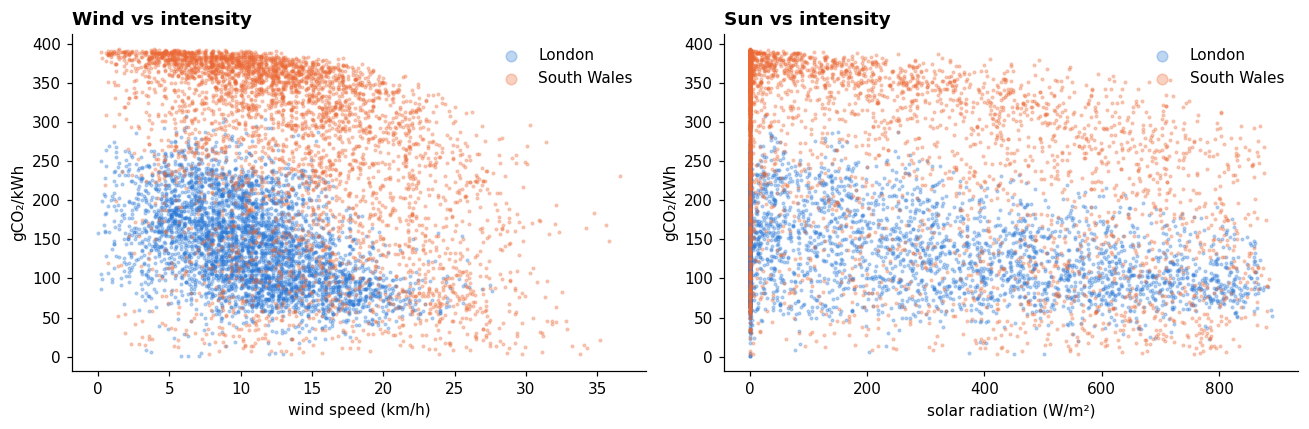

,wind_speed_10m,shortwave_radiation,temperature_2m,cloud_cover
region,,,,
London,-0.47,-0.36,0.00,-0.09
North_West_England,-0.36,-0.07,0.24,-0.13
South_Scotland,-0.29,0.10,0.09,-0.04
South_Wales,-0.51,-0.50,-0.10,-0.11
South_West_England,-0.34,-0.82,-0.30,-0.06


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for r, c in [("London", BLUE), ("South_Wales", ORANGE)]:
    m = merged[merged.region == r]
    axes[0].scatter(m.wind_speed_10m, m.value, s=3, alpha=0.3, color=c, label=r.replace("_", " "))
    axes[1].scatter(m.shortwave_radiation, m.value, s=3, alpha=0.3, color=c, label=r.replace("_", " "))
axes[0].set(xlabel="wind speed (km/h)", ylabel="gCO₂/kWh", title="Wind vs intensity")
axes[1].set(xlabel="solar radiation (W/m²)", ylabel="gCO₂/kWh", title="Sun vs intensity")
for a in axes:
    a.legend(frameon=False, markerscale=4)
plt.tight_layout()
plt.show()

# Spearman correlation of intensity with each weather variable, per region
weather_cols = ["wind_speed_10m", "shortwave_radiation", "temperature_2m", "cloud_cover"]
merged.groupby("region")[weather_cols + ["value"]].apply(
    lambda g: g[weather_cols].corrwith(g.value, method="spearman")).round(2)

>  **My notes**

>
> - **Wind:** as I expected, more wind goes with lower intensity in every region (−0.29 to −0.51). The effect is strongest in South Wales (−0.51) and London (−0.47). In the scatter plot, South Wales sits at the ~390 ceiling when it's calm, but drops a long way on windy days, when wind generation replaces gas.

> - **Sun:** the South West has a very strong link (−0.82), which matches its large midday dip in 4.3. South Wales (−0.50) and London (−0.36) are moderate, and the North West and Scotland show almost none. That fits solar being concentrated in the south-west.

> - **Temperature and cloud** are weak. The South West's −0.30 for temperature is probably because warm hours are also sunny hours, and cloud cover adds little beyond solar radiation.

> - **Caveat:**

*   Solar radiation is 0 every night, and night is when intensity is highest (the vertical stripe at 0 in the sun plot). So part of the solar correlation is really the daily cycle, not just sunshine. To separate them I'd need to control for hour of day, e.g. in a regression.

*   Each region's weather comes from one city, so it's only a rough proxy for conditions across the region.


*   South Scotland's values are almost all near 0, so its correlations mean little.

*   Correlation doesn't prove cause, though these links do match how the grid works (wind and solar displacing gas).







In [73]:
day = merged[merged.hour.between(9, 17)]
day.groupby("region")[weather_cols + ["value"]].apply(
    lambda g: g[weather_cols].corrwith(g.value, method="spearman")).round(2)

,wind_speed_10m,shortwave_radiation,temperature_2m,cloud_cover
region,,,,
London,-0.44,-0.15,-0.00,0.08
North_West_England,-0.39,0.05,0.20,-0.01
South_Scotland,-0.30,0.10,0.08,-0.03
South_Wales,-0.29,-0.25,0.01,0.02
South_West_England,-0.10,-0.57,-0.24,0.17


### 4.8 Green scheduling: what would CATS save?
For a 2-hour job, I compare starting it **now** with starting it at the best time in the next 24 hours.

In [70]:
from pandas.api.indexers import FixedForwardWindowIndexer as Ahead

JOB_STEPS = 4          # a 2-hour job = 4 half-hours
DAY_STEPS = 48         # I look 24 hours ahead = 48 half-hours

def savings(region_df):
    s = region_df.set_index("datetime").value.asfreq("30min")
    # average intensity if the job starts at each half-hour and runs for 2 hours
    job_now = s.rolling(Ahead(window_size=JOB_STEPS), min_periods=JOB_STEPS).mean()
    # the lowest of those averages over the next 24 hours (the best start time)
    job_best = job_now.rolling(Ahead(window_size=DAY_STEPS), min_periods=DAY_STEPS).min()
    out = pd.DataFrame({"now": job_now, "best": job_best}).dropna()
    out = out[out.now > 0]                                  # can't calculate a % saving from 0
    return (1 - out.best / out.now) * 100                   # % carbon saved by waiting

sav = {r: savings(best[best.region == r]) for r in order}
pd.DataFrame({"median % saving": {r: s.median() for r, s in sav.items()},
              "mean % saving": {r: s.mean() for r, s in sav.items()}}).round(0)

,median % saving,mean % saving
North_Scotland,100.0,79.0
South_Scotland,100.0,70.0
North_East_England,29.0,30.0
North_West_England,52.0,49.0
North_Wales_and_Merseyside,66.0,59.0
West_Midlands,63.0,56.0
Yorkshire,34.0,35.0
East_England,47.0,46.0
London,39.0,38.0
East_Midlands,45.0,43.0


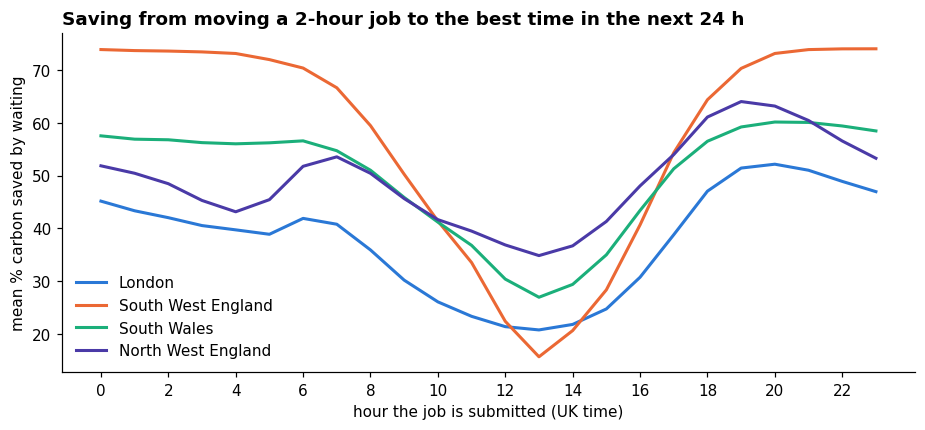

In [71]:
# When is waiting most worth it? I average the saving by the hour the job is submitted
fig, ax = plt.subplots(figsize=(10, 4))
for r, c in compare.items():
    s = sav[r]
    by_hour = s.groupby(s.index.tz_convert("Europe/London").hour).mean()
    ax.plot(by_hour.index, by_hour.values, lw=2, color=c, label=r.replace("_", " "))
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("hour the job is submitted (UK time)")
ax.set_ylabel("mean % carbon saved by waiting")
ax.set_title("Saving from moving a 2-hour job to the best time in the next 24 h")
ax.legend(frameon=False)
plt.show()

>  **My notes**
>
> Moving a 2-hour job to the best time in the next 24 hours saves a lot of carbon (median saving):
>
> | Region | Median saving |
> |---|---|
> | North Wales & Merseyside | 66% |
> | South West | 64% |
> | West Midlands | 63% |
> | North West | 52% |
> | South Wales | 51% |
> | London | 39% |
> | South East | 37% |
> | Yorkshire | 34% |
> | North East | 29% |
>
> - **Timing matters.** Waiting is most worthwhile for jobs submitted in the **evening**: London saves 52% if submitted at 20:00, and the South West 74% at 23:00, because the job can move to the next midday. Jobs submitted around **13:00** save the least (London 21%, South West 16%), because they're already at the cleanest time.
> - **Caveat:** Scotland shows about 100%, but that's misleading. When intensity is almost 0, any small value makes the percentage huge, and the absolute saving in grams is tiny.
> - These savings use forecasts. Since early forecasts are revised by about 20 g (4.6), the real savings could be a bit different.

## 5. Conclusions & limitations

>  **My notes**
>
> **Main findings**
> 1. **Where matters:** carbon intensity rises from about 0 g in Scotland to about 270 g in South Wales. Scotland is cleaner than London on every single day (4.1, 4.5).
> 2. **When matters:** every region is cleanest around 13:00 and dirtiest at 20:00–22:00. The South West swings almost 4× within a day (4.3). Weekends are about 10–20% cleaner in most regions (4.4).
> 3. **Green scheduling works:** moving a 2-hour job to the best time in the next 24 hours saves a median of about **30–65%**, most for jobs submitted in the evening (4.8).
> 4. **Forecasts are useful but biased:** a day-ahead forecast changes by about 20 g on average and tends to be too low (4.6).
> 5. **Data quality:** *an issue that basic checks miss*. Following the short files led me to 26 frozen runs (364 files) in which the source forecast had stopped updating. They passed every standard check (no missing values, no duplicates), and were only visible when I asked whether each run actually changed anything. Removing them mattered most for the forecast analysis (4.6), where they would have made forecasts look more stable than they are. Lesson: check that a time series is genuinely updating, not just that it's complete.
>
> **Limitations**
> - There are gaps (37 missing runs and 3 half-hours with no forecast), and I removed 26 frozen runs.
> - Each region is represented by one postcode.
> - The weather comes from one city per region.
> - The data only covers April–September, so there's no winter.
